# Limits of Sequences

This notebook follows the same style as the previous notebooks and introduces the idea of the **limit of a sequence**.

It covers:

- what a sequence is
- intuitive examples of convergence
- divergent sequences
- the formal definition of a limit
- how to interpret the $\varepsilon$-$N$ definition
- examples of convergent and divergent sequences
- uniqueness of the limit
- Python plots and numerical experiments


## 1. What is a sequence?

A **sequence** is an infinite ordered list of terms.

Usually, we study numerical sequences:

$$
a_1, a_2, a_3, \dots
$$

where the $n$-th term is often described by a formula $a_n$.

Examples:

$$
a_n = \frac{1}{2^n}
$$

and

$$
b_n = \frac{n-1}{n}.
$$

The main question in this topic is:

> What happens to the terms of the sequence as $n \to \infty$?


## 2. Intuitive idea of a limit

A sequence has limit $A$ if its terms get closer and closer to $A$ as $n$ becomes large.

This does **not** mean the terms have to become equal to $A$.

It means:

- the difference between $a_n$ and $A$ becomes arbitrarily small
- after some point, all remaining terms are as close to $A$ as we want


## 3. First example: $a_n = \frac{1}{2^n}$

Consider the sequence

$$
a_n = \frac{1}{2^n}
$$

Its first few terms are:

$$
\frac12, \frac14, \frac18, \frac1{16}, \dots
$$

These terms get smaller and smaller, so the sequence tends to 0.


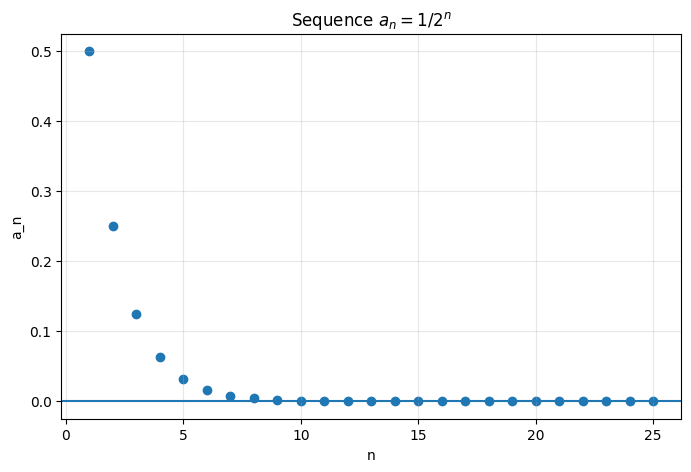

First 10 terms:
a_1 = 0.5000000000
a_2 = 0.2500000000
a_3 = 0.1250000000
a_4 = 0.0625000000
a_5 = 0.0312500000
a_6 = 0.0156250000
a_7 = 0.0078125000
a_8 = 0.0039062500
a_9 = 0.0019531250
a_10 = 0.0009765625


In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = np.arange(1, 26)
a = 1 / (2**n)

plt.figure(figsize=(8,5))
plt.scatter(n, a)
plt.axhline(0)
plt.title(r"Sequence $a_n = 1/2^n$")
plt.xlabel("n")
plt.ylabel("a_n")
plt.grid(True, alpha=0.3)
plt.show()

print("First 10 terms:")
for i in range(10):
    print(f"a_{i+1} = {a[i]:.10f}")


## 4. Second example: $b_n = \frac{n-1}{n}$

Now consider

$$
b_n = \frac{n-1}{n}.
$$

We can rewrite it as

$$
b_n = 1 - \frac{1}{n}.
$$

So the difference from 1 is

$$
1 - b_n = \frac{1}{n},
$$

which goes to 0.

Therefore:

$$
\lim_{n\to\infty} \frac{n-1}{n} = 1.
$$


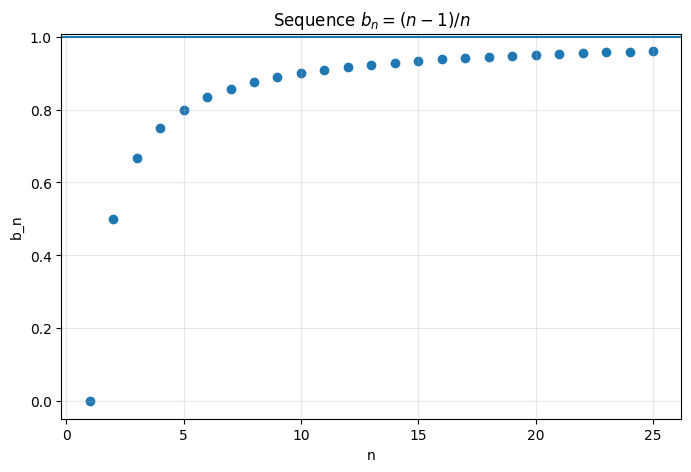

First 10 terms:
b_1 = 0.0000000000
b_2 = 0.5000000000
b_3 = 0.6666666667
b_4 = 0.7500000000
b_5 = 0.8000000000
b_6 = 0.8333333333
b_7 = 0.8571428571
b_8 = 0.8750000000
b_9 = 0.8888888889
b_10 = 0.9000000000


In [2]:
n = np.arange(1, 26)
b = (n - 1) / n

plt.figure(figsize=(8,5))
plt.scatter(n, b)
plt.axhline(1)
plt.title(r"Sequence $b_n = (n-1)/n$")
plt.xlabel("n")
plt.ylabel("b_n")
plt.grid(True, alpha=0.3)
plt.show()

print("First 10 terms:")
for i in range(10):
    print(f"b_{i+1} = {b[i]:.10f}")


## 5. A divergent sequence: $c_n = (-1)^n$

Consider the sequence

$$
c_n = (-1)^n.
$$

Its terms alternate:

$$
-1, 1, -1, 1, -1, 1, \dots
$$

This sequence does **not** approach any single number.

So it has **no limit** and is called **divergent**.


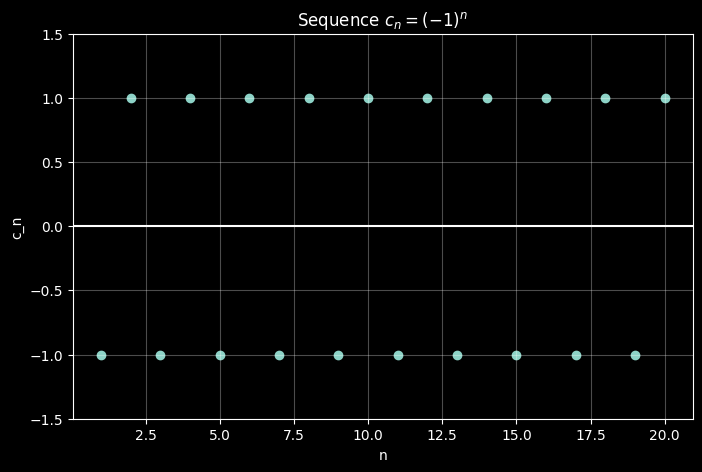

In [3]:
n = np.arange(1, 21)
c = (-1)**n

plt.figure(figsize=(8,5))
plt.scatter(n, c)
plt.axhline(0)
plt.title(r"Sequence $c_n = (-1)^n$")
plt.xlabel("n")
plt.ylabel("c_n")
plt.ylim(-1.5, 1.5)
plt.grid(True, alpha=0.3)
plt.show()


## 6. Convergent vs divergent sequences

A sequence is:

- **convergent** if it has a limit
- **divergent** if it has no limit

Examples:

- $\frac{1}{2^n}$ converges to 0
- $\frac{n-1}{n}$ converges to 1
- $(-1)^n$ diverges


## 7. Formal definition of the limit

A number $A$ is the limit of the sequence $(a_n)$ if:

> for every $\varepsilon > 0$, there exists an $N$ such that for all $n > N$,
 $$
 |a_n - A| < \varepsilon.
 $$

This is written as:

$$
\lim_{n\to\infty} a_n = A.
$$


## 8. Interpreting the $\varepsilon$-$N$ definition

This definition says:

- choose any precision $\varepsilon > 0$
- then we can find a point $N$
- after that point, every term of the sequence lies within distance $\varepsilon$ of the limit

So the tail of the sequence fits inside the interval:

$$
(A-\varepsilon, A+\varepsilon).
$$


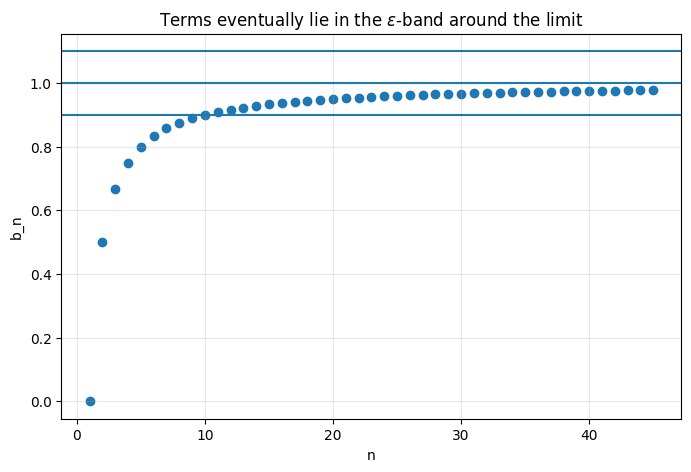

One possible N for epsilon=0.1 is: 9


In [3]:
n = np.arange(1, 46)
b = (n - 1) / n
A = 1
eps = 0.1

plt.figure(figsize=(8,5))
plt.scatter(n, b)
plt.axhline(A)
plt.axhline(A + eps)
plt.axhline(A - eps)
plt.title(r"Terms eventually lie in the $\varepsilon$-band around the limit")
plt.xlabel("n")
plt.ylabel("b_n")
plt.grid(True, alpha=0.3)
plt.show()

for N in range(1, 100):
    tail_ok = all(abs(((k-1)/k) - A) < eps for k in range(N+1, 100))
    if tail_ok:
        print("One possible N for epsilon=0.1 is:", N)
        break


## 9. Example with a non-monotone convergent sequence

Now consider the sequence

$$
a_n =
\begin{cases}
\frac{1}{n}, & \text{if } n \text{ is even} \\
\frac{1}{2n}, & \text{if } n \text{ is odd}
\end{cases}
$$

This sequence is not monotone: odd and even terms behave differently.

But both formulas still go to 0, so the whole sequence tends to 0.


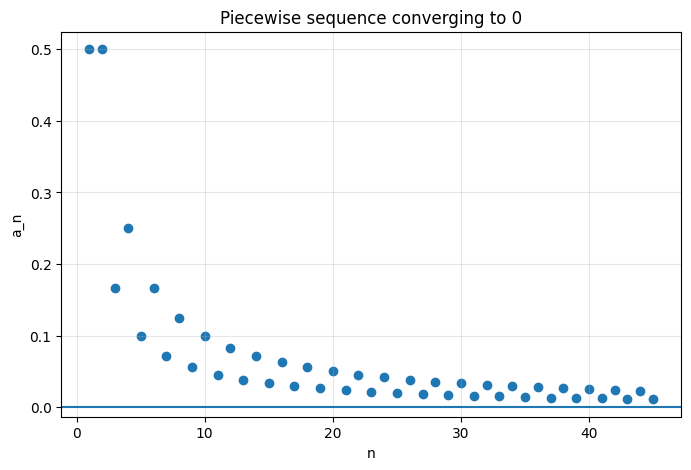

First 12 terms:
a_1 = 0.500000
a_2 = 0.500000
a_3 = 0.166667
a_4 = 0.250000
a_5 = 0.100000
a_6 = 0.166667
a_7 = 0.071429
a_8 = 0.125000
a_9 = 0.055556
a_10 = 0.100000
a_11 = 0.045455
a_12 = 0.083333


In [4]:
def seq_piecewise(n):
    if n % 2 == 0:
        return 1 / n
    else:
        return 1 / (2*n)

n = np.arange(1, 46)
vals = np.array([seq_piecewise(k) for k in n])

plt.figure(figsize=(8,5))
plt.scatter(n, vals)
plt.axhline(0)
plt.title("Piecewise sequence converging to 0")
plt.xlabel("n")
plt.ylabel("a_n")
plt.grid(True, alpha=0.3)
plt.show()

print("First 12 terms:")
for k in range(1, 13):
    print(f"a_{k} = {seq_piecewise(k):.6f}")


## 10. Why the previous sequence converges to 0

We want to show:

$$
|a_n - 0| < \varepsilon
$$

for all large enough $n$.

Since:

- if $n$ is even, then $a_n = \frac{1}{n}$
- if $n$ is odd, then $a_n = \frac{1}{2n}$

both are smaller than $\frac{1}{n}$.

So if we choose

$$
N > \frac{1}{\varepsilon},
$$

then for all $n > N$ we get

$$
a_n < \varepsilon.
$$


## 11. A more subtle divergent sequence

Consider the sequence

$$
b_n =
\begin{cases}
\frac{1}{10}, & \text{if } n \text{ is divisible by } 10 \\
\frac{1}{n}, & \text{otherwise}
\end{cases}
$$

This sequence does **not** have a limit.

Why?

Because:

- many terms go close to 0
- but every 10th term jumps back to $\frac{1}{10}$

So no single number can capture all tails of the sequence.


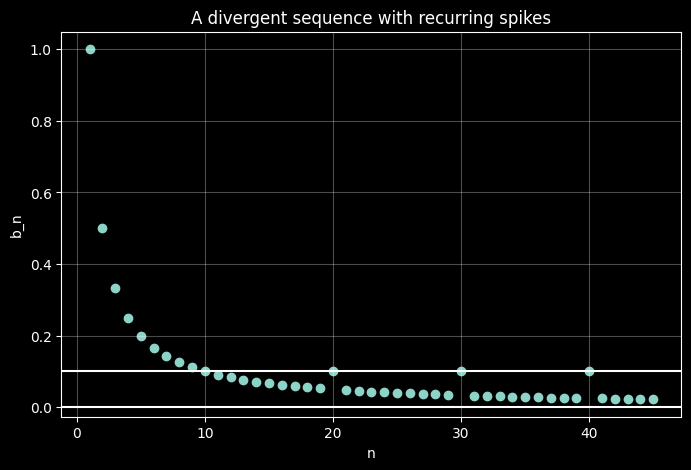

In [7]:
def seq_divisible_by_10(n):
    if n % 10 == 0:
        return 1/10
    else:
        return 1/n

n = np.arange(1, 46)
vals = np.array([seq_divisible_by_10(k) for k in n])

plt.figure(figsize=(8,5))
plt.scatter(n, vals)
plt.axhline(0)
plt.axhline(0.1)
plt.title("A divergent sequence with recurring spikes")
plt.xlabel("n")
plt.ylabel("b_n")
plt.grid(True, alpha=0.3)
plt.show()


## 12. Why the previous sequence has no limit

It cannot converge to 0, because infinitely many terms are equal to

$$
\frac{1}{10}.
$$

It cannot converge to $\frac{1}{10}$, because infinitely many non-multiple-of-10 terms get close to 0.

And it cannot converge to any other number either, because the sequence keeps producing terms near 0 and terms equal to $\frac{1}{10}$ forever.


## 13. Uniqueness of the limit

A sequence cannot have two different limits.

Suppose, for contradiction, that $(a_n)$ had two limits:

$$
A \neq A'.
$$

Choose

$$
\varepsilon = \frac{|A-A'|}{2}.
$$

Then:

- eventually all terms must lie within $\varepsilon$ of $A$
- eventually all terms must also lie within $\varepsilon$ of $A'$

But those two neighborhoods cannot both contain the same tail unless $A=A'$, which is a contradiction.

So a sequence has:

- either exactly one limit
- or no limit


## 14. Numerical experiment for the definition

Let us test how large $N$ should be for the sequence

$$
a_n = \frac{1}{2^n}
$$

to satisfy

$$
|a_n - 0| < \varepsilon
$$

for all $n > N$.


In [5]:
def min_N_for_eps_power_of_two(eps, max_search=100):
    for N in range(max_search):
        if all((1/(2**n)) < eps for n in range(N+1, max_search+1)):
            return N
    return None

epsilons = [0.1, 0.01, 0.001, 1e-5]
for eps in epsilons:
    print(f"epsilon = {eps}, one possible N = {min_N_for_eps_power_of_two(eps)}")


epsilon = 0.1, one possible N = 3
epsilon = 0.01, one possible N = 6
epsilon = 0.001, one possible N = 9
epsilon = 1e-05, one possible N = 16


## 15. Numerical experiment for $b_n = \frac{n-1}{n}$

Now test:

$$
\left|\frac{n-1}{n} - 1\right| < \varepsilon.
$$

Since

$$
\left|\frac{n-1}{n} - 1\right| = \frac{1}{n},
$$

we expect the same kind of behavior as for $1/n$.


In [8]:
def min_N_for_eps_b(eps, max_search=500):
    for N in range(max_search):
        if all(abs(((n-1)/n) - 1) < eps for n in range(N+1, max_search+1)):
            return N
    return None

epsilons = [0.1, 0.05, 0.01, 0.001]
for eps in epsilons:
    print(f"epsilon = {eps}, one possible N = {min_N_for_eps_b(eps)}")


epsilon = 0.1, one possible N = 9
epsilon = 0.05, one possible N = 20
epsilon = 0.01, one possible N = 100
epsilon = 0.001, one possible N = None


## 16. Small exercises

1. Does the sequence
$$
a_n = \frac{3}{n}
$$
converge? If yes, to what?

2. Does the sequence
$$
a_n = 5 + \frac{1}{n}
$$
converge? If yes, to what?

3. Does the sequence
$$
a_n = (-1)^n
$$
converge?

4. Explain why a sequence cannot have two different limits.


In [11]:
print("1. 3/n converges to 0")
print("2. 5 + 1/n converges to 5")
print("3. (-1)^n does not converge")
print("4. If two different limits existed, the same tail would have to stay close to both, which is impossible.")


1. 3/n converges to 0
2. 5 + 1/n converges to 5
3. (-1)^n does not converge
4. If two different limits existed, the same tail would have to stay close to both, which is impossible.


## 17. Summary

You learned:

- a sequence is an infinite ordered list of terms
- a sequence converges if its terms approach a single number
- the formal definition uses the $\varepsilon$-$N$ condition
- some sequences converge even if they are not monotone
- some sequences diverge because they keep oscillating or jumping
- a sequence can have at most one limit

The concept of limit is fundamental in analysis and is the basis for continuity, derivatives, integrals, and much more.
